# Notebook 4: Filtrado de imágenes

**Autor:** Dr. Mitchell Ángel Gómez Ortega

**Asignatura:** Sistemas de Visión Artificial

**Tema:** Filtros en procesamiento digital de imágenes

---

## Objetivo

Comprender el uso de filtros en imágenes digitales para modificar, mejorar o resaltar características visuales, tales como bordes, suavizado, nitidez y reducción de ruido.

---

## Contenido

1. Introducción a los filtros
2. Operaciones de vecindad o barrios
3. Suavizado de imágenes
4. Filtro Gaussiano
5. Detección de bordes
6. Filtro Sobel
7. Comparación entre imagen original e imagen filtrada

## Importación de librerías

```python
from skimage import data, color, filters
import matplotlib.pyplot as plt
```

In [1]:
from pickle import BUILD

from skimage import data, color, filters
import matplotlib.pyplot as plt

## Función para comparar imágenes

```python
def plot_comparison(original, filtered, title_filtered):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

    ax1.imshow(original, cmap='gray')
    ax1.set_title('Imagen original')
    ax1.axis('off')

    ax2.imshow(filtered, cmap='gray')
    ax2.set_title(title_filtered)
    ax2.axis('off')

    plt.show()
```

In [1]:
def plot_comparison(original, filtered, title_filtered):
    fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(10, 5), sharex=True, sharey=True)

    ax1.imshow(original, cmap='gray')
    ax1.set_title('Imagen original')
    ax1.axis('off')

    ax2.imshow(filtered, cmap='gray')
    ax2.set_title(title_filtered)
    ax2.axis('off')

    plt.show()

# Detección de bordes con el filtro Sobel

La detección de bordes es una técnica utilizada en procesamiento digital de imágenes para identificar cambios bruscos de intensidad en una imagen.

Los bordes normalmente representan:
- límites de objetos
- cambios de textura
- contornos
- formas importantes dentro de la imagen

---

## Filtro Sobel

El filtro Sobel es uno de los algoritmos más utilizados para la detección de bordes.

Este filtro calcula cambios de intensidad entre píxeles vecinos para resaltar:
- contornos
- siluetas
- regiones con cambios abruptos de brillo
- https://scikit-image.org/docs/stable/api/skimage.filters.html

---

## Flujo de trabajo

```text
Imagen RGB
        ↓
Conversión a escala de grises
        ↓
Aplicación del filtro Sobel
        ↓
Detección de bordes
```

---

## Código

```python
from skimage import color
from skimage.filters import sobel
import matplotlib.pyplot as plt

# Cargar imagen
soaps_image = plt.imread('../Images/soaps.jpg')

# Convertir a escala de grises
soaps_image_gray = color.rgb2gray(soaps_image)

# Aplicar filtro Sobel
edge_sobel = sobel(soaps_image_gray)

# Comparar resultados
plot_comparison(soaps_image_gray,
                edge_sobel,
                'Edges with Sobel')
```

---

## Explicación

```python
color.rgb2gray()
```

Convierte la imagen RGB a escala de grises.

---

```python
sobel()
```

Aplica el filtro Sobel para detectar bordes mediante cambios de intensidad entre píxeles vecinos.

---

```python
plot_comparison()
```

Permite comparar de manera visual:
- la imagen original
- la imagen filtrada

reduciendo código repetitivo y facilitando el análisis de resultados.

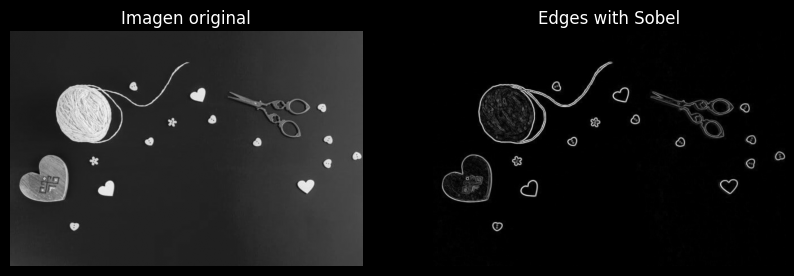

In [2]:
from skimage import color
from skimage.filters import sobel
import matplotlib.pyplot as plt

# Cargar imagen
soaps_image = plt.imread('../Images/shapes52.jpg')

# Convertir a escala de grises
soaps_image_gray = color.rgb2gray(soaps_image)

# Aplicar filtro Sobel
edge_sobel = sobel(soaps_image_gray)

# Comparar resultados
plot_comparison(soaps_image_gray,
                edge_sobel,
                'Edges with Sobel')

# Suavizado de imágenes con filtro Gaussiano

El filtro Gaussiano es una técnica utilizada para suavizar imágenes y reducir detalles de alta frecuencia.

Este filtro permite:
- reducir ruido
- disminuir nitidez
- suavizar transiciones
- preparar imágenes para etapas posteriores de procesamiento

---

## Idea principal

El filtro Gaussiano realiza un promedio ponderado entre píxeles vecinos utilizando una distribución Gaussiana.

Como resultado:
- los bordes se suavizan
- las texturas se reducen
- la imagen pierde nitidez

---

## Flujo de trabajo

```text
Imagen original
        ↓
Aplicación del filtro Gaussiano
        ↓
Imagen suavizada
```

---

## Código

```python
from skimage.filters import gaussian
import matplotlib.pyplot as plt

# Cargar imagen
building_image = plt.imread('../Images/building_image.jpg')

# Aplicar filtro Gaussiano
gaussian_image = gaussian(building_image,
                          channel_axis=-1)

# Comparar resultados
plot_comparison(building_image,
                gaussian_image,
                'Reduced sharpness Gaussian')
```

---

## Explicación

```python
gaussian()
```

Aplica un suavizado Gaussiano sobre la imagen.

---

```python
channel_axis=-1
```

Indica que la última dimensión de la imagen corresponde a los canales RGB.

---

## Resultado esperado

La imagen resultante presentará:
- menor nitidez
- bordes más suaves
- reducción de detalles finos
- apariencia difuminada

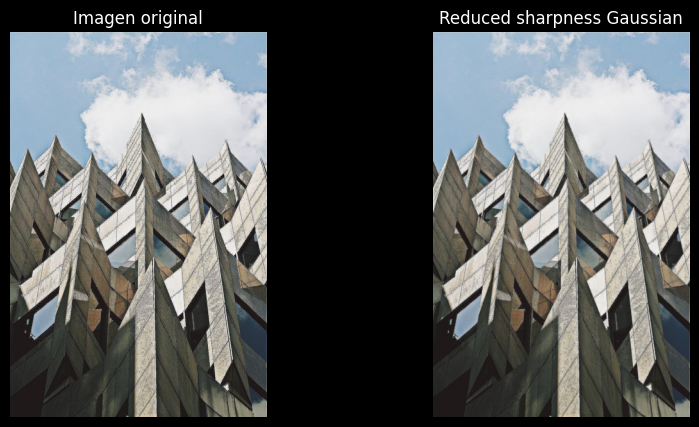

(1728, 1152, 3)
(1728, 1152, 3)


In [9]:
from skimage.filters import gaussian
import matplotlib.pyplot as plt

# Cargar imagen
building_image = plt.imread('../Images/building_image.jpg')

# Aplicar filtro Gaussiano
gaussian_image = gaussian(building_image,
                          channel_axis=-1)

# Comparar resultados
plot_comparison(building_image,
                gaussian_image,
                'Reduced sharpness Gaussian')
print(building_image.shape)
print(gaussian_image.shape)

# Filtro Gaussiano por canales RGB e histogramas

En este ejercicio se separan los tres canales de color de la imagen `building_image`:

- Canal rojo
- Canal verde
- Canal azul

Después, se aplica el filtro Gaussiano a cada canal por separado y se visualiza su histograma correspondiente.

---

## Código

```python
from skimage.filters import gaussian
import matplotlib.pyplot as plt

# Separar canales RGB
red_channel = building_image[:, :, 0]
green_channel = building_image[:, :, 1]
blue_channel = building_image[:, :, 2]

# Aplicar filtro Gaussiano a cada canal
red_gaussian = gaussian(red_channel)
green_gaussian = gaussian(green_channel)
blue_gaussian = gaussian(blue_channel)

# Crear figura
plt.figure(figsize=(15, 8))

# Canal rojo con filtro Gaussiano
plt.subplot(2, 3, 1)
plt.imshow(red_gaussian, cmap='gray')
plt.title('Canal Rojo con Gaussiano')
plt.axis('off')

# Canal verde con filtro Gaussiano
plt.subplot(2, 3, 2)
plt.imshow(green_gaussian, cmap='gray')
plt.title('Canal Verde con Gaussiano')
plt.axis('off')

# Canal azul con filtro Gaussiano
plt.subplot(2, 3, 3)
plt.imshow(blue_gaussian, cmap='gray')
plt.title('Canal Azul con Gaussiano')
plt.axis('off')

# Histograma canal rojo
plt.subplot(2, 3, 4)
plt.hist(red_gaussian.ravel(), bins=256)
plt.title('Histograma Rojo')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

# Histograma canal verde
plt.subplot(2, 3, 5)
plt.hist(green_gaussian.ravel(), bins=256)
plt.title('Histograma Verde')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

# Histograma canal azul
plt.subplot(2, 3, 6)
plt.hist(blue_gaussian.ravel(), bins=256)
plt.title('Histograma Azul')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

# Ajustar espacios
plt.tight_layout()

# Mostrar resultado
plt.show()
```

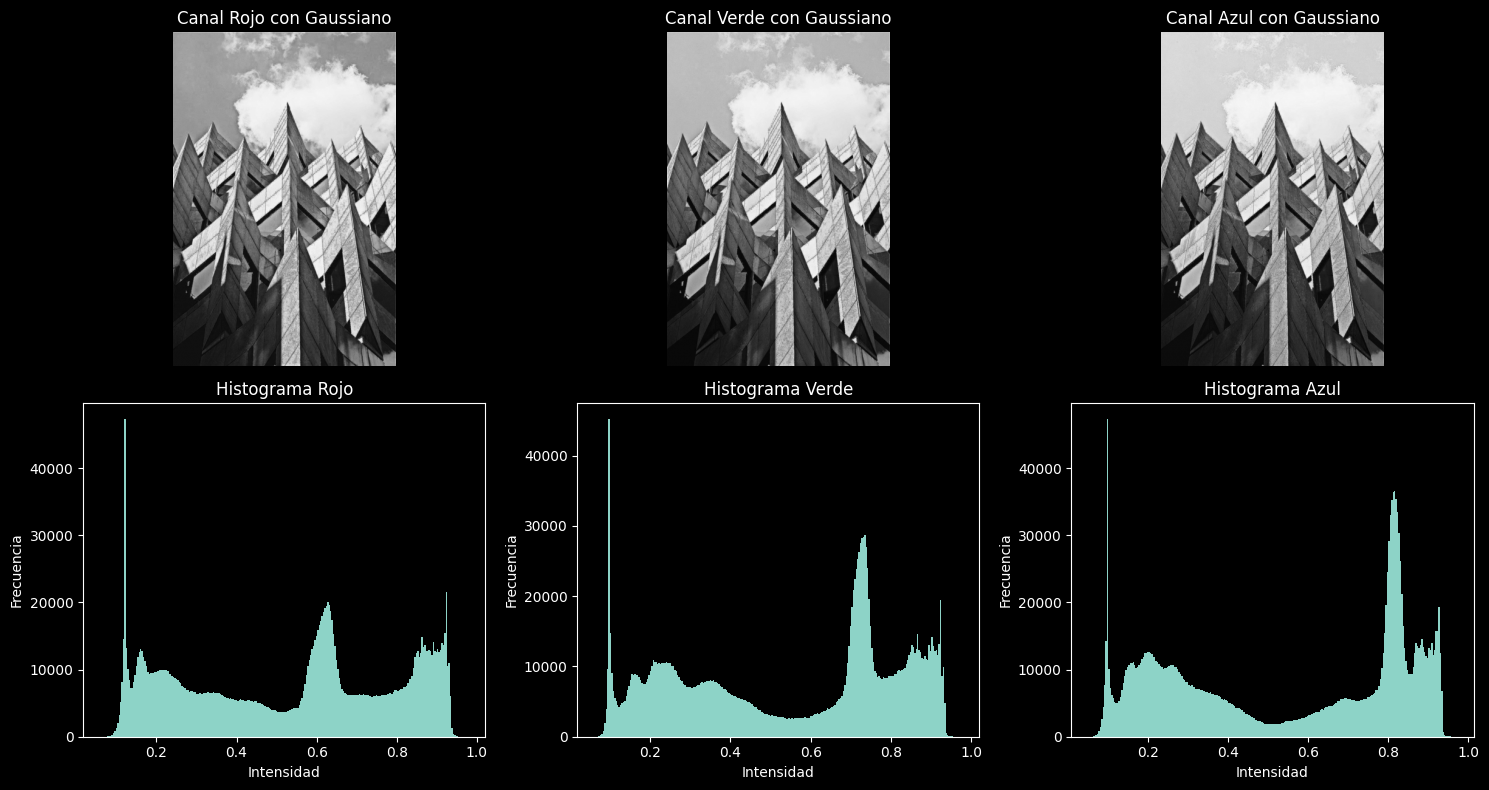

In [11]:
from skimage.filters import gaussian
import matplotlib.pyplot as plt

# Separar canales RGB
red_channel = building_image[:, :, 0]
green_channel = building_image[:, :, 1]
blue_channel = building_image[:, :, 2]

# Aplicar filtro Gaussiano a cada canal
red_gaussian = gaussian(red_channel)
green_gaussian = gaussian(green_channel)
blue_gaussian = gaussian(blue_channel)

# Crear figura
plt.figure(figsize=(15, 8))

# Canal rojo con filtro Gaussiano
plt.subplot(2, 3, 1)
plt.imshow(red_gaussian, cmap='gray')
plt.title('Canal Rojo con Gaussiano')
plt.axis('off')

# Canal verde con filtro Gaussiano
plt.subplot(2, 3, 2)
plt.imshow(green_gaussian, cmap='gray')
plt.title('Canal Verde con Gaussiano')
plt.axis('off')

# Canal azul con filtro Gaussiano
plt.subplot(2, 3, 3)
plt.imshow(blue_gaussian, cmap='gray')
plt.title('Canal Azul con Gaussiano')
plt.axis('off')

# Histograma canal rojo
plt.subplot(2, 3, 4)
plt.hist(red_gaussian.ravel(), bins=256)
plt.title('Histograma Rojo')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

# Histograma canal verde
plt.subplot(2, 3, 5)
plt.hist(green_gaussian.ravel(), bins=256)
plt.title('Histograma Verde')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

# Histograma canal azul
plt.subplot(2, 3, 6)
plt.hist(blue_gaussian.ravel(), bins=256)
plt.title('Histograma Azul')
plt.xlabel('Intensidad')
plt.ylabel('Frecuencia')

# Ajustar espacios
plt.tight_layout()

# Mostrar resultado
plt.show()